In [10]:
#Preparacion del entorno
import pandas as pd
import importlib
import sys
import os
sys.path.append(os.path.abspath(".."))

#Lectura de data sin limpiar (csv)
ruta= "../data/7_agro_intelligence.csv"
df=pd.read_csv(ruta, encoding="utf-8")
df.head()


,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,radiacion_solar,riego_litros,tipo_fertilizante,incidencia_plagas,diametro_fruto,peso_promedio,clima_estacion,target_calidad
0,7.442717,99.284022,29.334788,33.721312,52.914131,789.617461,41.171687,Quimico,4,78.024791,132.968735,Otoño,Desecho
1,7.118756,80.727691,72.571158,187.244301,68.698308,726.344929,39.490360,Ninguno,0,55.931444,161.824062,Primavera,Local
2,7.962388,41.149582,38.826847,105.805747,43.814550,622.682020,23.218546,Quimico,3,57.877056,158.672667,Otoño,Desecho
3,5.852164,107.106583,8.085960,14.673031,25.055747,466.099834,22.528966,Organico,2,66.608103,125.912912,Otoño,Desecho
4,7.073193,63.764436,9.385407,112.107266,41.059125,967.402102,6.686242,Quimico,3,58.975205,122.484854,Primavera,Exportacion


In [11]:
df.columns

Index(['ph_suelo', 'nitrogeno', 'fosforo', 'potasio', 'humedad_suelo',
       'radiacion_solar', 'riego_litros', 'tipo_fertilizante',
       'incidencia_plagas', 'diametro_fruto', 'peso_promedio',
       'clima_estacion', 'target_calidad'],
      dtype='str')

In [12]:
df.dtypes

ph_suelo             float64
nitrogeno            float64
fosforo              float64
potasio              float64
humedad_suelo        float64
radiacion_solar      float64
riego_litros         float64
tipo_fertilizante        str
incidencia_plagas      int64
diametro_fruto       float64
peso_promedio        float64
clima_estacion           str
target_calidad           str
dtype: object

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
q1 = df['peso_promedio'].quantile(0.25)
q3 = df['peso_promedio'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df['peso_promedio'] < limite_inferior) | (df['peso_promedio'] > limite_superior)]

outliers

,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,radiacion_solar,riego_litros,tipo_fertilizante,incidencia_plagas,diametro_fruto,peso_promedio,clima_estacion,target_calidad
213,5.715926,26.384668,6.602137,24.850272,12.708985,404.148166,17.144052,Ninguno,4,76.180200,65.198103,Primavera,Local
364,6.720164,147.710102,41.084747,113.223628,67.847953,114.288537,8.403676,Quimico,0,64.056923,241.428907,Primavera,Exportacion
466,6.505816,56.795508,25.325301,124.770191,44.661517,585.616831,31.853862,Quimico,1,71.876983,231.398094,Otoño,Local
748,7.639195,62.938547,67.686232,122.523754,13.461787,887.814478,25.472984,Organico,2,79.872305,238.659506,Primavera,Local
780,6.742017,126.120822,49.052545,135.149250,50.826601,355.073130,12.448767,Ninguno,1,71.702696,67.621631,Primavera,Local
806,6.596372,97.714422,29.867904,111.947422,11.597380,237.064526,33.701254,Organico,0,77.531481,235.301716,Primavera,Exportacion
962,6.448652,131.228517,59.769983,161.610633,62.324414,918.880210,43.075929,Quimico,4,79.783681,267.482298,Primavera,Local
1035,6.571494,62.451550,31.560655,59.084708,50.021127,991.293113,17.250044,Organico,0,62.054603,235.393952,Otoño,Desecho
1080,6.568636,104.864020,28.103643,121.489265,54.249388,912.468082,19.247963,Ninguno,3,62.866044,236.332506,Primavera,Exportacion


In [15]:
q1 = df['humedad_suelo'].quantile(0.25)
q3 = df['humedad_suelo'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df['humedad_suelo'] < limite_inferior) | (df['humedad_suelo'] > limite_superior)]

outliers

,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,radiacion_solar,riego_litros,tipo_fertilizante,incidencia_plagas,diametro_fruto,peso_promedio,clima_estacion,target_calidad


In [16]:
q1 = df['riego_litros'].quantile(0.25)
q3 = df['riego_litros'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df['riego_litros'] < limite_inferior) | (df['riego_litros'] > limite_superior)]

outliers



,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,radiacion_solar,riego_litros,tipo_fertilizante,incidencia_plagas,diametro_fruto,peso_promedio,clima_estacion,target_calidad


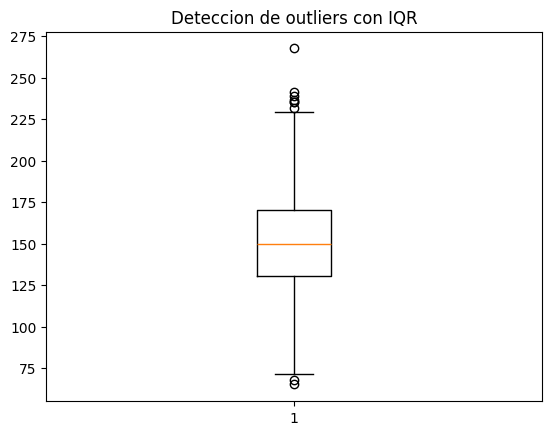

In [20]:
import matplotlib.pyplot as plt
plt.boxplot(df["peso_promedio"].dropna())
plt.title("Deteccion de outliers con IQR")
plt.show()

In [19]:
df.describe()

,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,radiacion_solar,riego_litros,incidencia_plagas,diametro_fruto,peso_promedio
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,6.753027,80.448673,52.455742,103.577957,46.008138,557.181744,27.458897,2.023333,69.758893,150.769836
std,0.725120,39.993012,26.920868,54.416104,20.459542,259.619037,13.058426,1.379991,9.786493,30.041517
min,5.500653,10.037881,5.133375,10.102451,10.068062,100.399254,5.045989,0.000000,41.800826,65.198103
25%,6.095255,45.184634,29.421712,57.513516,28.054231,328.870681,16.159081,1.000000,62.938061,130.452230
50%,6.795727,79.632423,54.120419,103.383931,46.613305,555.122058,27.788427,2.000000,69.847029,149.891963
75%,7.372961,115.045126,74.235898,152.258194,64.466458,786.797413,38.554139,3.000000,76.612568,170.156464
max,7.993263,149.874496,99.987384,199.617021,79.896565,999.872623,49.954472,4.000000,100.256957,267.482298
